# COGS 108 - EDA Checkpoint

## Authors
- Jenny Nguyen: Writing - original draft, Data curation, Background research
- Ocean Fang: Background research, Writing - original draft
- James Vidal: Data Curation, Analysis
- Evan Dorton:
- John De Castro: Background research, Data curation

# Research Question

Do individuals who use wearable fitness trackers report greater alignment between perceived and actual physical activity levels, and does this vary by socioeconomic status and health self efficacy? 

## Background and Prior Work

<h3>Ideal Dataset</h3>

The ideal dataset for this project would be a large scale cross sectional survey of consenting U.S. adults capturing variables such as:

- Wearable tracker use - binary variable (yes/no), frequency (daily, weekly, rarely), monitored metrics (steps, calories, heartrate)
- Perceived physical activity - self-rated activity level
- Actual physical activity - validated self-report measure or accelerometer data
- Socioeconomic status (SES) - household income bracket, educational attainment, employment status
- Demographic / controls - age, gender, race/ethnicity, geographic region, BMI

**Observations needed:** 1,000-1,500 respondents or more would be needed to detect the hypothesized effects with sufficient statistical reliability.

**Collection method:** Data would be collected by a random sample survey. The survey should be nationally representative and is adminstered online and by phone. Recruitment would target adult age groups, diverse income, and a wide range of SES factors.

**Storage/organization:** Data would be stored in a CSV format, with one row per respondent and columns for each variable. Personally identifiable information would be removed prior to analysis. 

<h3>Potential Datasets</h3>

1. Health Information National Trends Survey (HINTS)
- Available at: https://hints.cancer.gov/data/default.aspx
- publicly available, no application required
- HINTS is a nationally representative survey administered by the National Cancer Institute that specifically tracks a plethora of health categories. Importantly, in the more recent cycles (since HINTS 5 cycle 3), this includes use of health technology, including wearable devices and fitness apps. It contains variables on fitness tracker ownership and use frequency, perceived health behaviors, health self-efficacy, and sociodemographic characteristics. This makes HINTS the closest real-world match to the ideal dataset for this project. Data is available for immediate download in CSV and SAS formats as well. This would likely serve as the primary dataset for the project.
2. Behavioral Risk Factor Surveillance System (BRFSS)
- Available at: https://www.cdc.gov/brfss/data_documentation/index.htm
- publicly available, no application required
- The BRFSS is an annual CDC telephone survey of over 400,000 U.S. adults, making it one of the largest health-related survey datasets in the world. It includes self-reported physical activity levels, demographic variables, income, education, and health status measures highly relevant to this project. 
It does not directly ask about wearable tracker ownership, physical activity perception and actual activity variables can be operationalized from existing questions. Its enormous sample size makes it exceptionally well-suited for subgroup and moderation analysis by SES. Data is freely downloadable in SAS XPT format and can be converted to CSV for use in Python or R.
3. National Health Interview Survey (NHIS)
- Available at: https://www.cdc.gov/nchs/nhis/documentation/?CDC_AAref_Val=https://www.cdc.gov/nchs/nhis/data--questionnaires-documentation.htm 
- publicly available, no application required
- The NHIS is a large household-based survey conducted annually by the CDC's National Center for Health Statistics, covering over 25,000 households per year. It includes detailed physical activity frequency and duration variables, self-rated health measures, income, education, and insurance status as SES indicators. This set also does not include a direct wearable variable, but it has the richest set of physical activity measurement of the three sets here, and will be used to validate or supplement foundational findings in HINTS. 

# Hypothesis


We predict that individuals who use wearable fitness trackers will report greater alignment between their perceived and actual physical activity levels compared to non-users. However, we expect this benefit to be significantly moderated by socioeconomic status (SES) and health self-efficacy. Specifically, we anticipate that higher-SES individuals with greater health self-efficacy will demonstrate the strongest alignment between self perceived and actual activity, while lower-SES individuals will show weaker alignment even when tracker use is present. This reflects disparities in device access, engagement quality, and the social conditions under which feedback loops are effective. This prediction is mainly founded on background studies that show how tracker benefits are most pronounced in supported, resource-rich environments, and that cost and awareness barriers disproportionately limit meaningful tracker engagement.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [ ]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
%pip install requests tqdm gdown

import sys
sys.path.append('./modules')
import get_data

# datafiles = [
#     { 'url': 'https://dl.dropboxusercontent.com/scl/fi/nx143pk4tgosig6evul3x/hints7_public.dta?rlkey=csathvka5g82ejmjotv0zcxs8', 'filename':'2024 BRFFS.XPT'},
#     { 'url': 'https://dl.dropboxusercontent.com/scl/fi/nx143pk4tgosig6evul3x/hints7_public.dta?rlkey=csathvka5g82ejmjotv0zcxs8', 'filename':'hints7_public.dta'},
# ]

get_data.get_raw(datafiles, destination_directory='data/00-raw/')

Overall Download Progress:   0%|          | 0/2 [00:00<?, ?it/s]
                                                                           

Successfully downloaded: airline-safety.csv



Overall Download Progress: 100%|██████████| 2/2 [00:00<00:00, 21.50it/s]

Successfully downloaded: bad-drivers.csv


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

### Behavioral dataset

 - Dataset Name: Behavioral Risk Factor Surveillance System (BRFSS) - 2024
 - Link to Dataset: https://www.cdc.gov/brfss/data_documentation/index.htm
 - Number of Observations: 457,670 respondents
 - Number of Variables: 345 variables
 - Description of Variables Most Relevant to This Project: 
   - Exercise in Past 30 Days (EXERANY2) - Indicates whether respondents participated in physical activities or exercise outside of regular employment during the past month. Responses are categorical (1 = Yes, 2 = No). Approximately 77% of respondents reported exercising in the past 30 days.
   - Income Level (INCOME3) - Annual household income grouped into income brackets ranging from less than $10,000 to $200,000+. This variable may be useful for measuring socioeconomic status (SES).
   - Education Level (EDUCA) - Highest completed education level, ranging from elementary education to college graduation. This may serve as an additional measure of SES and health literacy.
   - General Health (GENHLTH) - Self-reported health status measured categorically from Excellent to Poor. This may help contextualize physical activity behavior and perceived wellness.
   - Body Mass Index (_BMI5) - Computed BMI derived from respondent height and weight. BMI is reported in kg/m² (with two implied decimal places) and may be useful as a health-related outcome variable.
  - Potential Shortcomings: A major limitation of BRFSS is that the data is self-reported, meaning exercise behavior, health status, and other variables may be subject to reporting bias or inaccuracies. Additionally, the dataset does not appear to directly measure wearable fitness tracker ownership, which is central to our research question. Because of this, wearable usage may need to be approximated through proxy variables or the research question may need to be slightly refined if this dataset is selected. The dataset also contains some missingness and nonresponse patterns. For example, income variables include “Refused” and “Don’t Know” responses, while BMI is missing for respondents who did not provide height or weight measurements.

In [4]:
import pandas as pd
brffs = pd.read_sas('data/00-raw/2024 BRFFS.XPT')
brffs

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457665,78.0,7.0,b'07122024',b'07',b'12',b'2024',1200.0,b'2024001344',2.024001e+09,NaN,...,NaN,NaN,9.0,9.000000e+02,9.0,9.990000e+04,9.0,9.0,9.0,NaN
457666,78.0,7.0,b'07182024',b'07',b'18',b'2024',1100.0,b'2024001345',2.024001e+09,NaN,...,4.0,2.0,1.0,1.000000e+02,9.0,3.500000e+03,2.0,2.0,2.0,1.0
457667,78.0,7.0,b'07172024',b'07',b'17',b'2024',1100.0,b'2024001346',2.024001e+09,NaN,...,4.0,9.0,1.0,7.000000e+00,1.0,1.400000e+02,1.0,1.0,1.0,2.0
457668,78.0,7.0,b'07202024',b'07',b'20',b'2024',1200.0,b'2024001347',2.024001e+09,NaN,...,NaN,NaN,9.0,9.000000e+02,9.0,9.990000e+04,9.0,NaN,NaN,NaN


In [5]:
print(brffs.shape)
print(brffs.info())

(457670, 301)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 1.0+ GB
None


In [6]:
clean_brffs = brffs[['EXERANY2', 'INCOME3', 'EDUCA', 'GENHLTH', '_BMI5']]
new_col = {
    'EXERANY2': 'Exercise', 
    'INCOME3': 'Income', 
    'EDUCA': 'Education', 
    'GENHLTH': 'General Health', 
    '_BMI5': 'BMI'
}
clean_brffs = clean_brffs.rename(columns=new_col)
clean_brffs = clean_brffs.dropna()
clean_brffs

,Exercise,Income,Education,General Health,BMI
0,1.0,99.0,4.0,3.0,2249.0
1,1.0,11.0,6.0,1.0,2583.0
2,1.0,99.0,5.0,2.0,2253.0
3,1.0,6.0,6.0,1.0,2509.0
4,2.0,3.0,5.0,3.0,1977.0
...,...,...,...,...,...
457664,2.0,2.0,4.0,5.0,2986.0
457666,2.0,6.0,2.0,4.0,2066.0
457667,2.0,8.0,6.0,3.0,2437.0
457668,1.0,10.0,5.0,1.0,2441.0


In [7]:
clean_brffs.info()
clean_brffs.value_counts()
clean_brffs.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 414628 entries, 0 to 457669
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Exercise        414628 non-null  float64
 1   Income          414628 non-null  float64
 2   Education       414628 non-null  float64
 3   General Health  414628 non-null  float64
 4   BMI             414628 non-null  float64
dtypes: float64(5)
memory usage: 19.0 MB


,Exercise,Income,Education,General Health,BMI
count,414628.000000,414628.000000,414628.000000,414628.000000,414628.000000
mean,1.243271,19.397433,5.054135,2.654618,2855.684180
std,0.525976,29.476651,1.020691,1.076759,658.616736
min,1.000000,1.000000,1.000000,1.000000,1200.000000
25%,1.000000,6.000000,4.000000,2.000000,2414.000000
50%,1.000000,8.000000,5.000000,3.000000,2744.000000
75%,1.000000,10.000000,6.000000,3.000000,3175.000000
max,9.000000,99.000000,9.000000,9.000000,9984.000000


In [8]:
clean_brffs.to_csv("data/02-processed/brffs.csv", index=False)

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [9]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Socioeconomic and Behavioral Patterns in Physical Activity - BRFFS EDA

This section is dedicated to exploring socioeconomic and behavioral patterns in our BFRSS dataset which are relevant to our research question. Our goal is to deeply examine key relationships between general health status, income, education, BMI, and excercise participation. It is key to note that although BRFSS doesn't specifically measure wearable fitness tracker usage, it still does provide important and relevant context for understanding just how socioeconomic and health behaviors can possibly influence physical activity patterns. 

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

clean_brffs['Exercise'] = clean_brffs['Exercise'].replace({
    1.0: 'Yes',
    2.0: 'No'
})

clean_brffs['General Health'] = clean_brffs['General Health'].replace({
    1.0: 'Excellent',
    2.0: 'Very Good',
    3.0: 'Good',
    4.0: 'Fair',
    5.0: 'Poor'
})

clean_brffs = clean_brffs[
    ~clean_brffs['General Health'].isin([7.0, 9.0])
] #cleaned bad response -> 7.0 (dont know) and 9.0 (refused) 

clean_brffs = clean_brffs[
    ~clean_brffs['Exercise'].isin([7.0, 9.0])
] #cleaned bad response -> 7.0 (dont know) and 9.0 (refused) 

#clean_brffs.head()

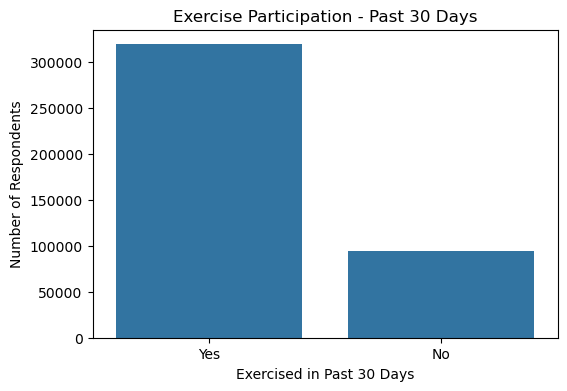

In [11]:
plt.figure(figsize = (6, 4))

sns.countplot(data = clean_brffs, x = 'Exercise')

plt.title('Exercise Participation - Past 30 Days')
plt.xlabel('Exercised in Past 30 Days')
plt.ylabel('Number of Respondents')

plt.show()

### Understanding Exercise Participation - Past 30 Days
The bar graph shows the distribution of respondents who have reported either participating (Yes) or did not participate (No) in physical activity / exercise within the past 30 days. Most respondents have reported in engaging in exercise, which suggests that physical activity behavior is relatively common in the BRFFS sample. Because exercise is central to our research question, understanding its overall distribution provides us with context prior to exploring relationships between health and socioeconomic variables. 

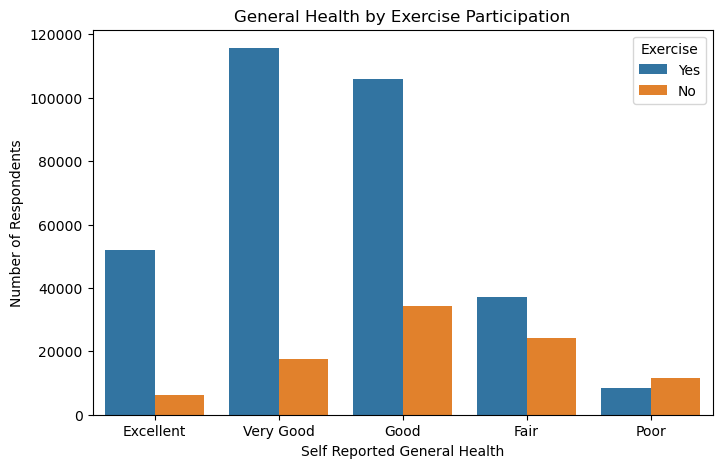

In [12]:
plt.figure(figsize = (8, 5))

sns.countplot(
    data = clean_brffs,
    x = 'General Health', 
    hue = 'Exercise',
    order = ['Excellent', 'Very Good', 'Good', 'Fair', 'Poor']
)

plt.title('General Health by Exercise Participation')
plt.xlabel('Self Reported General Health')
plt.ylabel('Number of Respondents')
plt.legend(title = 'Exercise')

plt.show()

### Understanding General Health by Exercise Participation
The bar graph shows a comparison of self reported general health between respondents who reported exercising vs. respondents who did not within the past 30 days. Among those who exercised (blue bars), their largest concentration appears to be in the "Very Good" and "Good" general health categories. Those who did not exercise (orange bars)  have their highest concentration in the "Good" category, though lower health categories such as "Fair" and "Poor" remain more visibly represented. Overall, these patterns suggest that exercise behavior may be associated with differences in how respondents percieve their general health, making general health an important variable to explore alongside physical activity in our broader research. 

In [13]:
clean_brffs['Income'] = clean_brffs['Income'].replace({
    1.0: '< $10k',
    2.0: '$10k-$15k',
    3.0: '$15k-$20k',
    4.0: '$20k-$25k',
    5.0: '$25k-$35k',
    6.0: '$35k-$50k',
    7.0: '$50k-$75k',
    8.0: '$75k-$100k',
    9.0: '$100k-$150k',
    10.0: '$150k-$200k',
    11.0: '$200k+'
})

clean_brffs = clean_brffs[
    ~clean_brffs['Income'].isin([77.0, 99.0])
] #77.0 = dont know, 99.0 = refused. cleaned

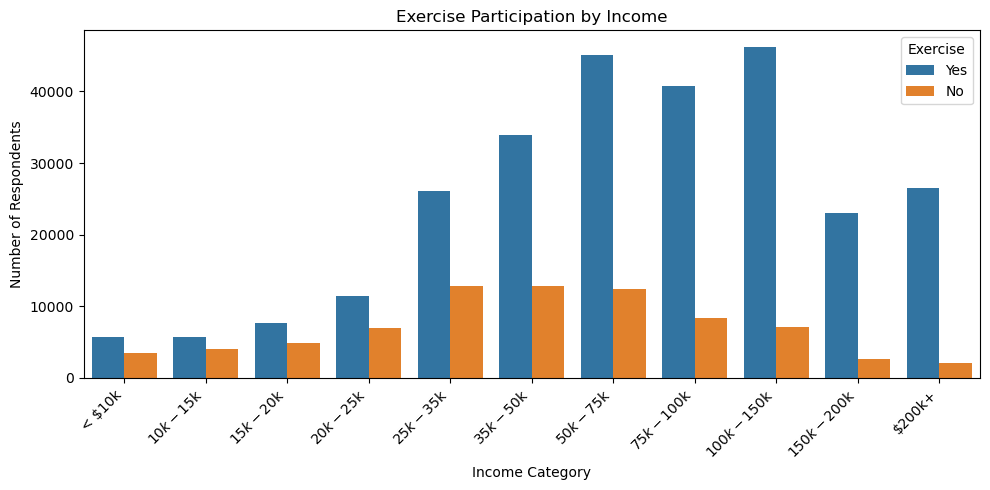

In [14]:
income_order = [
    '< $10k',
    '$10k-$15k',
    '$15k-$20k',
    '$20k-$25k',
    '$25k-$35k',
    '$35k-$50k',
    '$50k-$75k',
    '$75k-$100k',
    '$100k-$150k',
    '$150k-$200k',
    '$200k+'
]

plt.figure(figsize = (10, 5))

sns.countplot(
    data = clean_brffs,
    x = 'Income',
    hue = 'Exercise',
    order = income_order
)

plt.title('Exercise Participation by Income')
plt.xlabel('Income Category')
plt.ylabel('Number of Respondents')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.legend(title = 'Exercise')

plt.show()

### Understanding Exercise Participation by Income

This graph shows the comparison between exercise participation across differnt income levels. Across all of the income categories, we can see that respondents who reported exercising outnumber those who did not exercise. We can also notice that middle and higher income groups appear to show a much larger difference between respondents who exercised compared to those who did not, specifically those in the $50k - $150k income levels. While this graph shows raw counts rather than proportions, the pattern suggests that income may be associated with exercise behavior, making socioeconomic status an important factor to explore for our broader research.

## Ethics


### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> Yes, the datasets were in fact collected with informed consent from all participants. Each participants were indeed made aware of the utilization of their data they consented to, which would be used for research purposes. 

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> Since the datasets were survey-based, it would be resonable to suggest that they may have collection bias due to sampling methods, varying question interpretations, and other means. Due to this, we will acknowledge these possible biases and account for them during result interpretation.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> The datasets being used have already been de-identified prior to their public release in order to prevent unwanted exposure of all participants personally identifiable information. We will only be using variables relevant to our research question and have no motivation in attempting to re-identify individuals.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> Our research requires we look at demographic variables such as socioeconomic status, education, and possibly race in our analysis in order to evaluate how relationsups differ across groups. Doing so will enable us to highlight and discuss possible disparities amongst groups. 

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> The data we will work with are publicly available and have been de-identified, but we will continue to follow best practices for secure storage and restricted sharing. 

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> We acknowledge limitations, such as not fully capturing data from underrepresented populations and those without access to technology, and as such we will avoid overgeneralizing our findings to populations that are not well represented in our findings.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Yes, we consider the possible biases and will account for them when interpreting the results. Since the datasets are survey based, we are aware it may contain self-reporting bias, social desirability bias, and over estimations of physical activity and will account for them. 

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Our group will present these results using all appropriate statistical methods with clearly labeled vizualizations in order to avoid misleading interpretations and honestly represent the data as much as possible. 

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> Yes, since these datasets are de-identified prior to publication, these are minimal privacy risks. If at any instance PII data is discovered, we have no intention to display it and will not be included them in our findings. 

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> Yes, all analysis will be well documented and maintained through our GitHub repository, which will allow for reproducibility and transperancy. If issues do come up, all results will be able to be reviewed and verified. 


### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> We acknlowedge certain status variables, such as income and education, may act as proxies for other protected characteristics, and we will be cautious when viewing and interpreting such variables to avoid harmful conclusions that reinforce stereotypes. 

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> Our intention is to examine any differences among socioeconomic groups and report on any disparities found. In doing such, we will consider if our findings may have unequal implications across groups. 

 - [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
 - [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We will clearly communicate the limitations of our analysis, such as biases in the survey data, limitations to certain measurments in activities, and constraints in establishing casaul relationships. 


### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Team Expectations 

* *Primary communication will be through iMessage; all members are expected to respond in the form*
* *All members are expected to contribute equally to the project and individual tasks should be completeed at least 24 hours before the team deadline so there is time for review and integration*
* *All work pushed to the GitHub should be clean, commented, and readable before submission*Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 4/20  |  11 AM | Read & Think about COGS 108 expectations; brainstorm topics/questions  | Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| 4/22  |  11 AM |  Do background research on topic | Discuss ideal dataset(s) and ethics; draft project proposal | 
| 4/29  | 11 AM  | Edit, finalize, and submit proposal; Search for datasets  | Discuss Wrangling and possible analytical approaches; Assign group members to lead each specific part   |
| 5/10  | 11 AM  | Import & Wrangle Data (Ant Man); EDA (Hulk) | Review/Edit wrangling/EDA; Discuss Analysis Plan; Checkpoint #1   |
| 5/25  | 12 PM  | Finalize wrangling/EDA; Begin Analysis (Iron Man; Thor) | Discuss/edit Analysis; Complete project check-in for Checkpoint #2 |
| 5/29  | 12 PM  | Complete analysis; Draft results/conclusion/discussion (Wasp)| Discuss/edit full project |
| 6/9  | Before 11:59 PM  | Final edits, video | Turn in Final Project & Group Project Surveys |